# Diamonds Dataset — Data Preprocessing

Academic preprocessing pipeline on the full dataset.

**Rules:** no train/test split, no model training. All transformations apply to `df_clean = df.copy()` with before/after visualizations.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load data

In [2]:
# Load raw diamonds table from SQLite
DB_PATH = "diamonds.db"
TABLE_NAME = "diamonds"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(f"SELECT * FROM {TABLE_NAME}", conn)
conn.close()

print(f"Loaded table {TABLE_NAME!r} from {DB_PATH!r}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded table 'diamonds' from 'diamonds.db'
Shape: 53,940 rows × 11 columns


In [3]:
# First 5 rows of raw data
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
# Working copy — all preprocessing steps modify df_clean only
df_clean = df.copy()
print("Created df_clean = df.copy()")

Created df_clean = df.copy()


## 2. Drop unnecessary columns

In [5]:
# Drop index column (Unnamed: 0 or first unnamed column)
shape_before = df_clean.shape

cols_to_drop = []
if "Unnamed: 0" in df_clean.columns:
    cols_to_drop.append("Unnamed: 0")
else:
    unnamed = [c for c in df_clean.columns if str(c).startswith("Unnamed")]
    if unnamed:
        cols_to_drop.append(unnamed[0])

if cols_to_drop:
    df_clean = df_clean.drop(columns=cols_to_drop)
    print(f"Dropped columns: {cols_to_drop}")
else:
    print("No index column found to drop.")

shape_after = df_clean.shape
print(f"Shape before: {shape_before}")
print(f"Shape after:  {shape_after}")

Dropped columns: ['Unnamed: 0']
Shape before: (53940, 11)
Shape after:  (53940, 10)


## 3. Handle outliers (`x`, `y`, `z`)

In [6]:
# Helper: boxplots for dimension columns x, y, z
def plot_xyz_boxplots(data, title_suffix):
    dim_cols = [c for c in ["x", "y", "z"] if c in data.columns]
    fig, axes = plt.subplots(1, len(dim_cols), figsize=(5 * len(dim_cols), 5))
    if len(dim_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, dim_cols):
        sns.boxplot(x=data[col], ax=ax, color="steelblue")
        ax.set_title(f"Boxplot — {col} ({title_suffix})")
        ax.set_xlabel(col)
    plt.suptitle(f"Dimension outliers check — {title_suffix}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

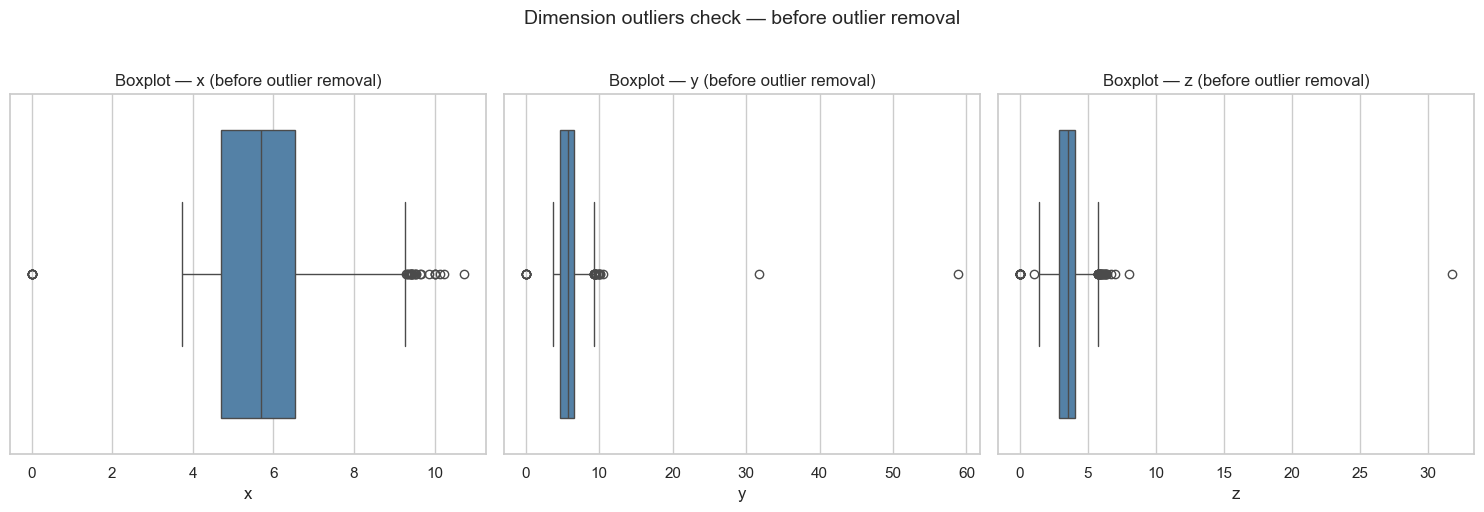

In [7]:
# BEFORE: boxplots for x, y, z
rows_before_outliers = len(df_clean)
plot_xyz_boxplots(df_clean, "before outlier removal")

In [8]:
# Remove physically impossible dimensions (x=0 OR y=0 OR z=0) and z > 10
mask_invalid = (df_clean["x"] == 0) | (df_clean["y"] == 0) | (df_clean["z"] == 0)
mask_z_outlier = df_clean["z"] > 10
mask_remove = mask_invalid | mask_z_outlier

n_invalid = mask_invalid.sum()
n_z_outlier = (mask_z_outlier & ~mask_invalid).sum()
n_removed = mask_remove.sum()

df_clean = df_clean.loc[~mask_remove].copy()
rows_after_outliers = len(df_clean)

print(f"Rows before: {rows_before_outliers:,}")
print(f"Removed (x=0 or y=0 or z=0): {n_invalid:,}")
print(f"Removed (z > 10, not already removed): {n_z_outlier:,}")
print(f"Total rows removed: {n_removed:,}")
print(f"Rows after: {rows_after_outliers:,}")

Rows before: 53,940
Removed (x=0 or y=0 or z=0): 20
Removed (z > 10, not already removed): 1
Total rows removed: 21
Rows after: 53,919


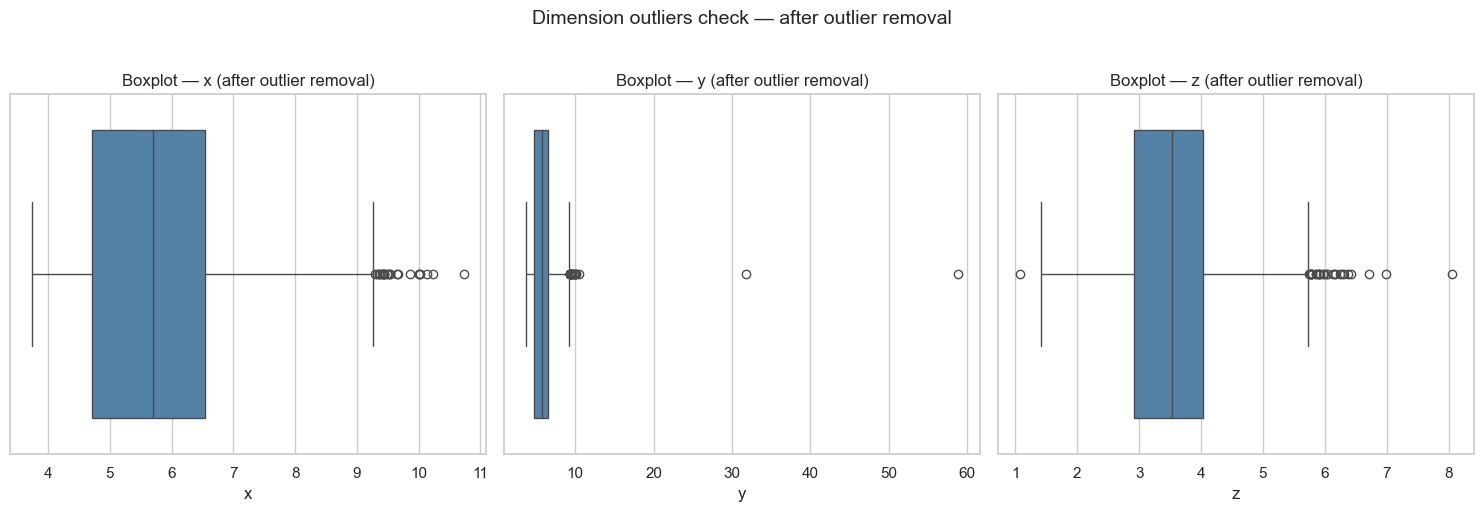

In [9]:
# AFTER: boxplots for x, y, z
plot_xyz_boxplots(df_clean, "after outlier removal")

## 4. Encode categorical columns (`cut`, `color`, `clarity`)

In [10]:
# Domain-knowledge ordinal mappings (low → high quality)
CUT_ORDER = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
COLOR_ORDER = ["J", "I", "H", "G", "F", "E", "D"]
CLARITY_ORDER = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

CUT_MAP = {v: i for i, v in enumerate(CUT_ORDER)}
COLOR_MAP = {v: i for i, v in enumerate(COLOR_ORDER)}
CLARITY_MAP = {v: i for i, v in enumerate(CLARITY_ORDER)}

CATEGORICAL_COLS = ["cut", "color", "clarity"]

In [11]:
# Helper: bar charts for categorical columns
def plot_categorical_bars(data, cols, title_suffix, use_str_labels=True):
    for col in cols:
        counts = data[col].value_counts().sort_index()
        fig, ax = plt.subplots(figsize=(10, 6))
        x_labels = counts.index.astype(str) if use_str_labels else counts.index
        sns.barplot(x=x_labels, y=counts.values, ax=ax, palette="viridis")
        ax.set_title(f"{col} — value counts ({title_suffix})")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

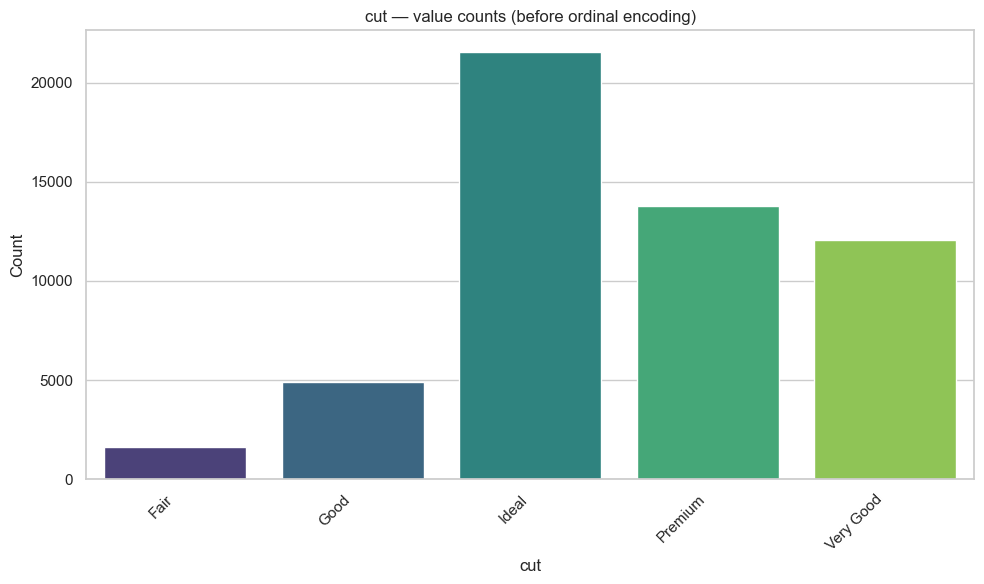

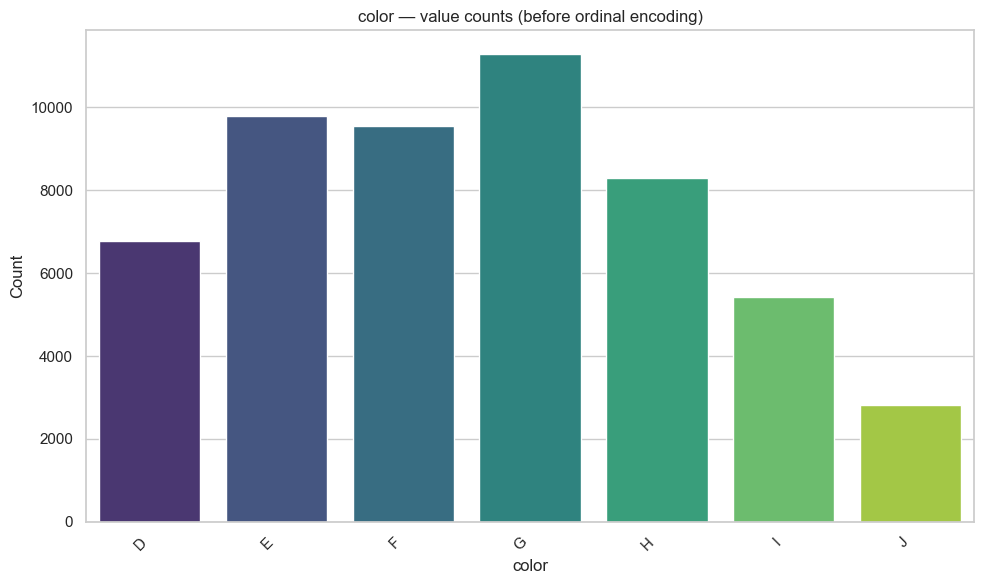

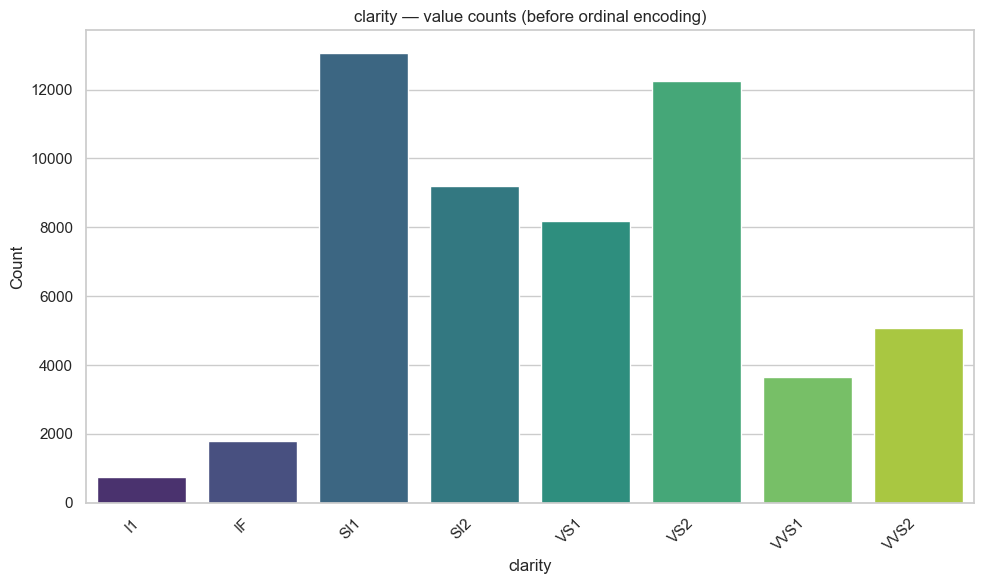

In [12]:
# BEFORE: bar charts with raw string labels
plot_categorical_bars(df_clean, CATEGORICAL_COLS, "before ordinal encoding", use_str_labels=True)

In [13]:
# Apply ordinal encoding (integer codes preserve quality order)
df_clean["cut"] = df_clean["cut"].map(CUT_MAP)
df_clean["color"] = df_clean["color"].map(COLOR_MAP)
df_clean["clarity"] = df_clean["clarity"].map(CLARITY_MAP)

print("Ordinal encoding applied to cut, color, clarity.")

Ordinal encoding applied to cut, color, clarity.


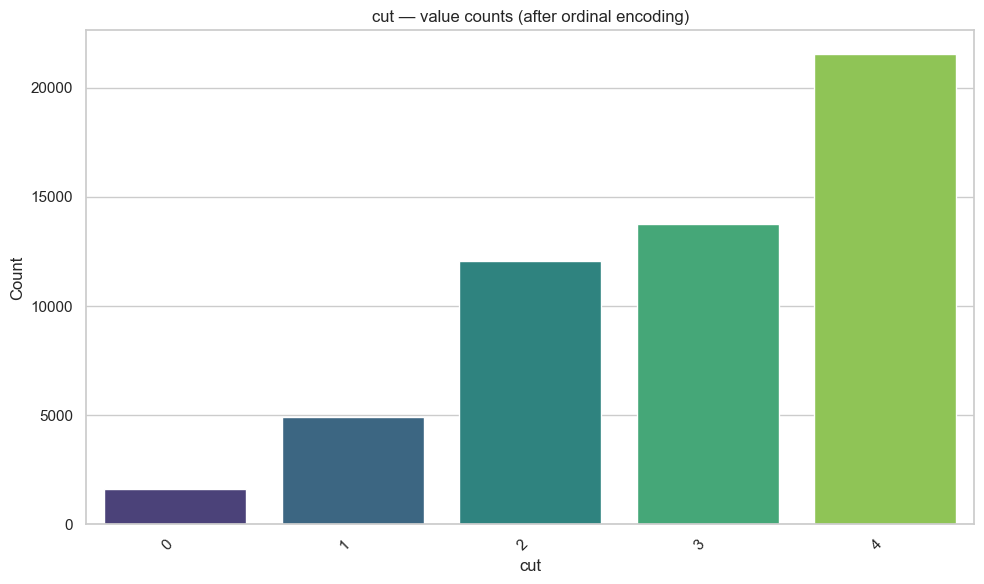

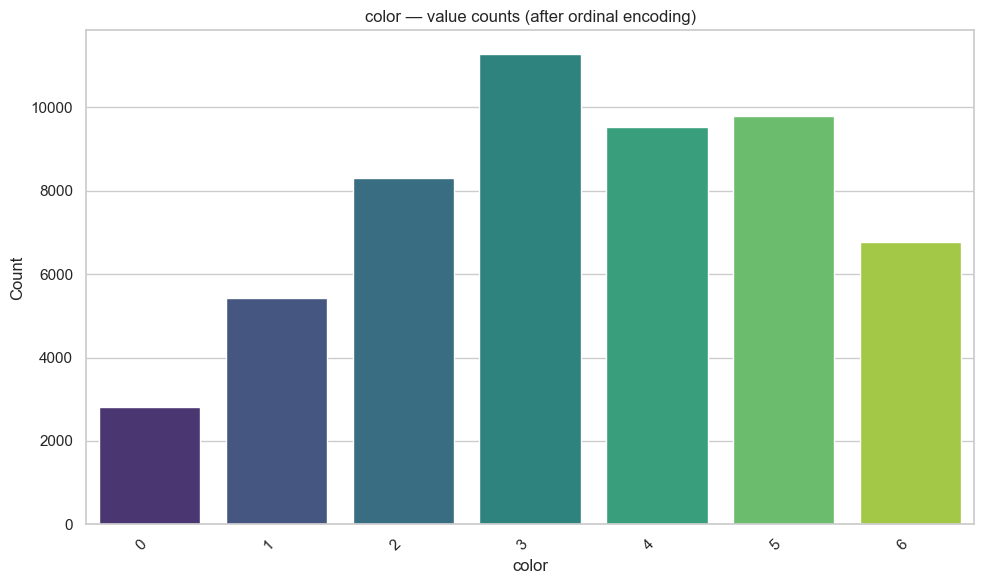

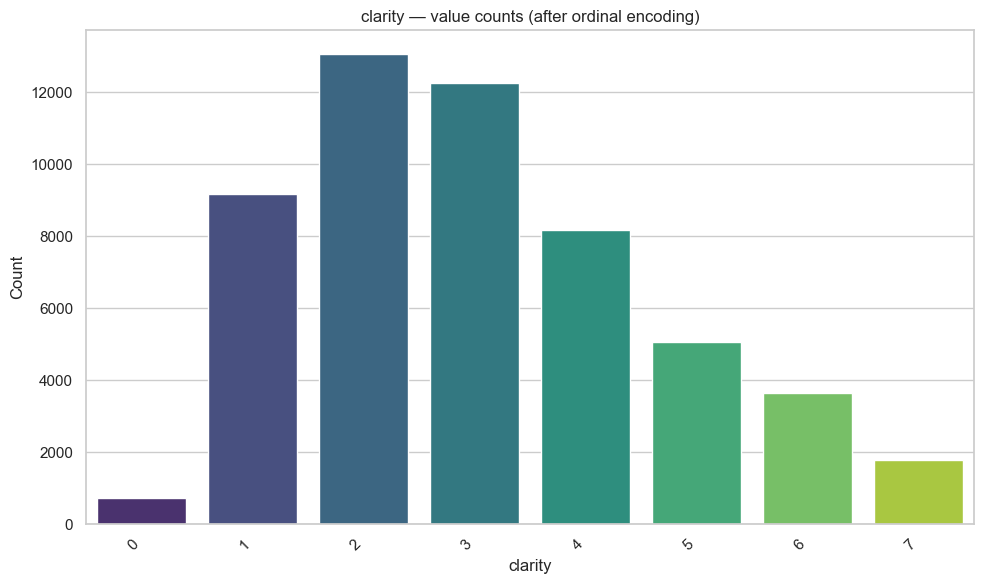

In [14]:
# AFTER: bar charts with encoded integer values
plot_categorical_bars(df_clean, CATEGORICAL_COLS, "after ordinal encoding", use_str_labels=False)

In [15]:
# Mapping tables: original label → encoded integer
def mapping_table(name, order):
    return pd.DataFrame({"label": order, "encoded_value": range(len(order))})

print("=== cut mapping ===")
display(mapping_table("cut", CUT_ORDER))
print("\n=== color mapping ===")
display(mapping_table("color", COLOR_ORDER))
print("\n=== clarity mapping ===")
display(mapping_table("clarity", CLARITY_ORDER))

=== cut mapping ===


,label,encoded_value
0,Fair,0
1,Good,1
2,Very Good,2
3,Premium,3
4,Ideal,4



=== color mapping ===


,label,encoded_value
0,J,0
1,I,1
2,H,2
3,G,3
4,F,4
5,E,5
6,D,6



=== clarity mapping ===


,label,encoded_value
0,I1,0
1,SI2,1
2,SI1,2
3,VS2,3
4,VS1,4
5,VVS2,5
6,VVS1,6
7,IF,7


## 5. Log transform on target (`price`)

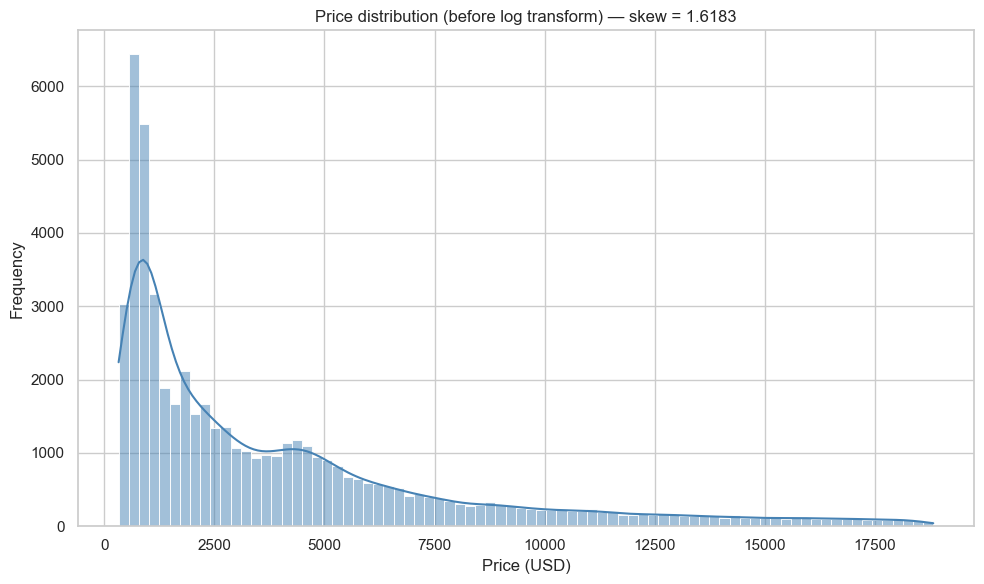

In [16]:
# BEFORE: price distribution and skewness
skew_price_before = df_clean["price"].skew()

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df_clean["price"], kde=True, ax=ax, color="steelblue", edgecolor="white")
ax.set_title(f"Price distribution (before log transform) — skew = {skew_price_before:.4f}")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [17]:
# Apply log1p transform; keep original price column
df_clean["log_price"] = np.log1p(df_clean["price"])
skew_price_after = df_clean["log_price"].skew()

print(f"Skewness — price (before):     {skew_price_before:.4f}")
print(f"Skewness — log_price (after):  {skew_price_after:.4f}")

Skewness — price (before):     1.6183
Skewness — log_price (after):  0.1161


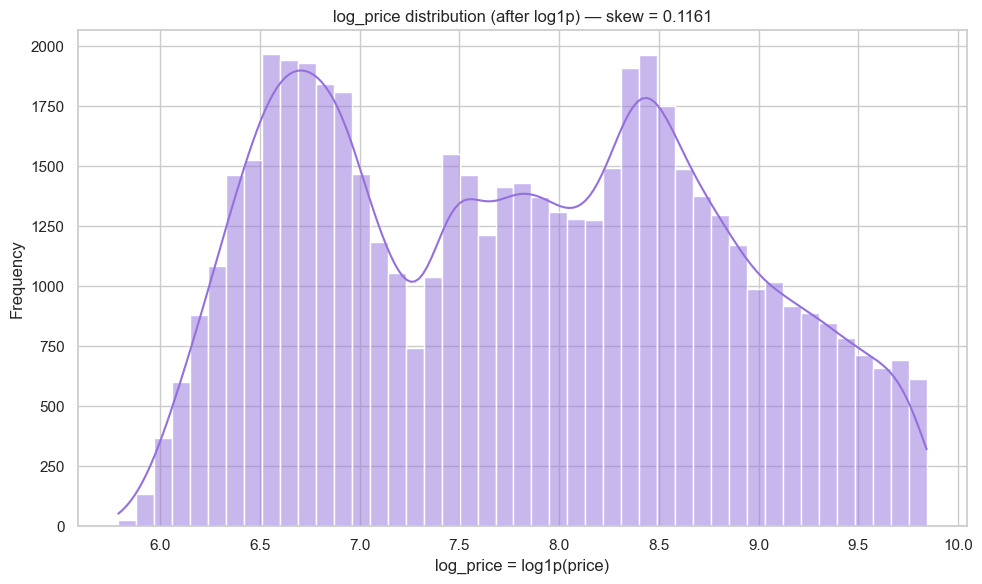

In [18]:
# AFTER: log_price distribution and skewness
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df_clean["log_price"], kde=True, ax=ax, color="mediumpurple", edgecolor="white")
ax.set_title(f"log_price distribution (after log1p) — skew = {skew_price_after:.4f}")
ax.set_xlabel("log_price = log1p(price)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## 6. Feature scaling (StandardScaler)

In [19]:
# Columns to scale (numerical + encoded categoricals; exclude price targets)
SCALE_COLS = [
    "carat", "depth", "table", "x", "y", "z",
    "cut", "color", "clarity",
]
SCALE_COLS = [c for c in SCALE_COLS if c in df_clean.columns]
print("Columns to scale:", SCALE_COLS)

Columns to scale: ['carat', 'depth', 'table', 'x', 'y', 'z', 'cut', 'color', 'clarity']


In [20]:
# Helper: distribution plots for features selected for scaling
def plot_scaling_distributions(data, cols, title_suffix):
    n = len(cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for i, col in enumerate(cols):
        sns.histplot(data[col], kde=True, ax=axes[i], color="teal", edgecolor="white")
        axes[i].set_title(f"{col} ({title_suffix})")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f"Feature distributions — {title_suffix}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

Mean and std BEFORE scaling:


,mean_before,std_before
carat,0.7977,0.4738
depth,61.7495,1.4323
table,57.4569,2.2341
x,5.7316,1.1194
y,5.7349,1.1401
z,3.5395,0.6919
cut,2.9042,1.1166
color,3.4059,1.7013
clarity,3.0515,1.6470


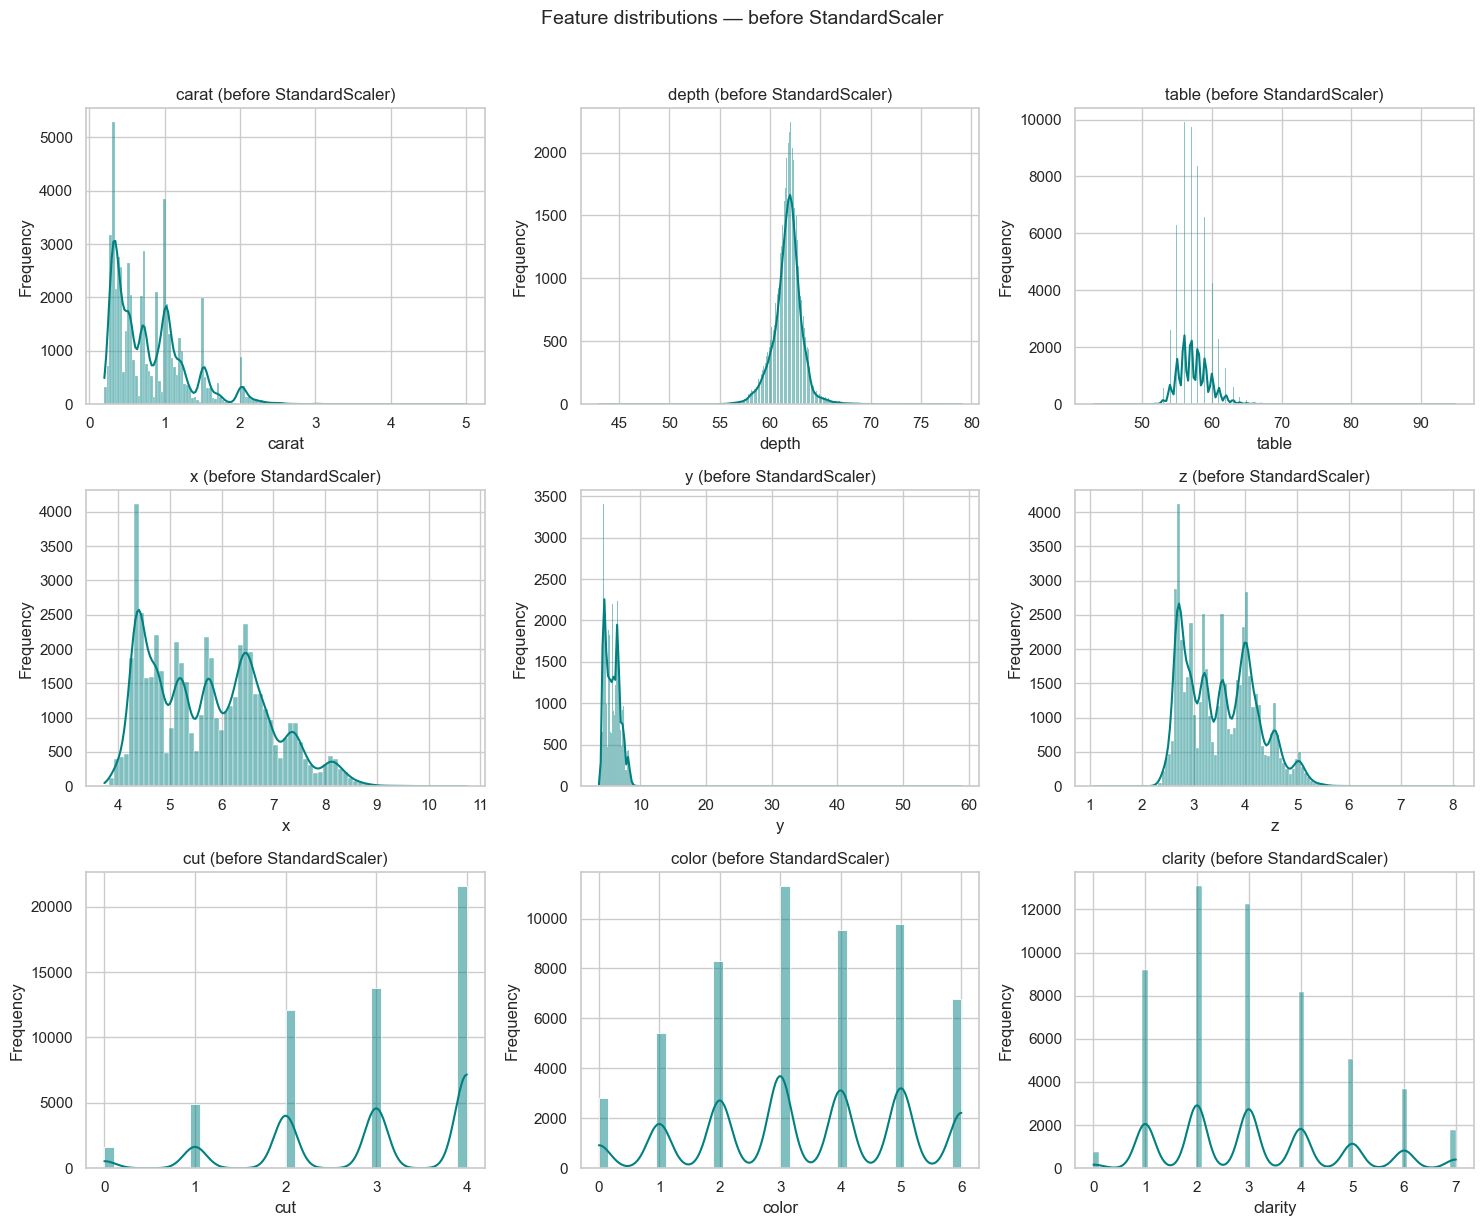

In [21]:
# BEFORE scaling: distributions and mean/std per column
stats_before = df_clean[SCALE_COLS].agg(["mean", "std"]).T
stats_before.columns = ["mean_before", "std_before"]
print("Mean and std BEFORE scaling:")
display(stats_before.round(4))

plot_scaling_distributions(df_clean, SCALE_COLS, "before StandardScaler")

In [22]:
# Fit StandardScaler on full dataset (no train/test split)
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_clean[SCALE_COLS])
df_clean[SCALE_COLS] = scaled_values

print("StandardScaler applied.")

StandardScaler applied.


Mean and std BEFORE vs AFTER scaling:


,mean_before,std_before,mean_after,std_after
carat,0.7977,0.4738,0.0,1.0
depth,61.7495,1.4323,0.0,1.0
table,57.4569,2.2341,-0.0,1.0
x,5.7316,1.1194,-0.0,1.0
y,5.7349,1.1401,-0.0,1.0
z,3.5395,0.6919,0.0,1.0
cut,2.9042,1.1166,-0.0,1.0
color,3.4059,1.7013,0.0,1.0
clarity,3.0515,1.6470,0.0,1.0


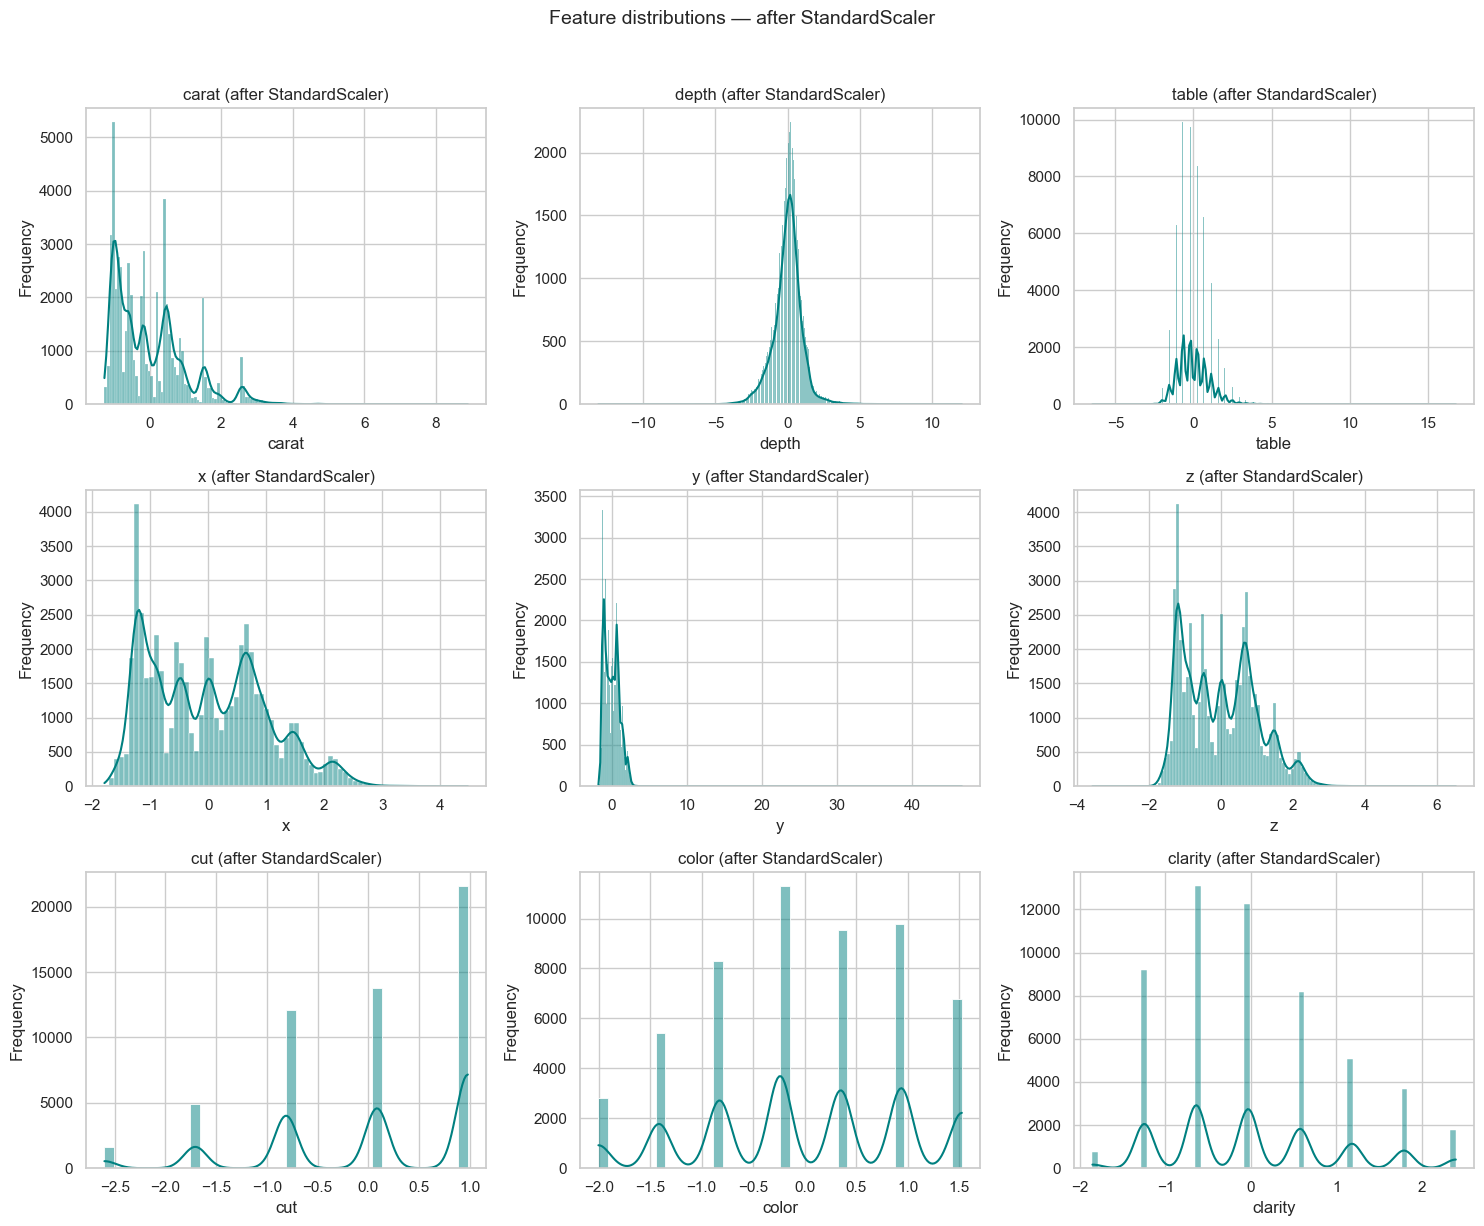

In [23]:
# AFTER scaling: distributions and mean/std (expect ~0 mean, ~1 std)
stats_after = df_clean[SCALE_COLS].agg(["mean", "std"]).T
stats_after.columns = ["mean_after", "std_after"]

scaling_comparison = stats_before.join(stats_after)
print("Mean and std BEFORE vs AFTER scaling:")
display(scaling_comparison.round(4))

plot_scaling_distributions(df_clean, SCALE_COLS, "after StandardScaler")

## 7. Final summary

In [24]:
print("=== df_clean.head() ===")
display(df_clean.head())

print(f"\n=== df_clean.shape ===\n{df_clean.shape}")

print("\n=== df_clean.dtypes ===")
display(df_clean.dtypes.to_frame(name="dtype"))

print("\n=== df_clean.describe() ===")
display(df_clean.describe().T.round(4))

=== df_clean.head() ===


,carat,cut,color,clarity,depth,table,price,x,y,z,log_price
0,-1.198208,0.981356,0.936987,-1.245589,-0.174201,-1.099754,326,-1.591573,-1.539218,-1.603568,5.789960
1,-1.240421,0.085758,0.936987,-0.638424,-1.361077,1.585973,326,-1.645172,-1.662012,-1.777002,5.789960
2,-1.198208,-1.705439,0.936987,0.575905,-3.385749,3.376457,327,-1.502241,-1.460279,-1.777002,5.793014
3,-1.071571,0.085758,-1.414213,-0.031260,0.454146,0.243110,334,-1.368243,-1.319943,-1.314513,5.814131
4,-1.029359,-1.705439,-2.002013,-1.245589,1.082492,0.243110,335,-1.243178,-1.214692,-1.141079,5.817111



=== df_clean.shape ===
(53919, 11)

=== df_clean.dtypes ===


,dtype
carat,float64
cut,float64
color,float64
clarity,float64
depth,float64
table,float64
price,int64
x,float64
y,float64
z,float64



=== df_clean.describe() ===


,count,mean,std,min,25%,50%,75%,max
carat,53919.0,0.0000,1.0000,-1.2615,-0.8394,-0.2062,0.5114,8.8906
cut,53919.0,-0.0000,1.0000,-2.6010,-0.8098,0.0858,0.9814,0.9814
color,53919.0,0.0000,1.0000,-2.0020,-0.8264,-0.2386,0.9370,1.5248
clarity,53919.0,0.0000,1.0000,-1.8528,-0.6384,-0.0313,0.5759,2.3974
depth,53919.0,0.0000,1.0000,-13.0902,-0.5233,0.0352,0.5240,12.0436
table,53919.0,-0.0000,1.0000,-6.4712,-0.6521,-0.2045,0.6907,16.8051
price,53919.0,3931.0296,3987.3085,326.0000,949.0000,2401.0000,5323.5000,18823.0000
x,53919.0,-0.0000,1.0000,-1.7881,-0.9126,-0.0283,0.7221,4.4741
y,53919.0,-0.0000,1.0000,-1.8023,-0.8902,-0.0218,0.7062,46.6310
z,53919.0,0.0000,1.0000,-3.5691,-0.9098,-0.0138,0.7233,6.5333


In [25]:
# Preprocessing checklist
checklist = [
    "[x] 1. Loaded data from diamonds.db (table: diamonds)",
    "[x] 2. Dropped index column (Unnamed: 0)",
    "[x] 3. Removed invalid/outlier rows (x/y/z = 0, z > 10)",
    "[x] 4. Ordinal-encoded cut, color, clarity",
    "[x] 5. Created log_price with np.log1p (kept original price)",
    "[x] 6. StandardScaled numerical + encoded features (excl. price, log_price)",
    "[x] 7. Final summary displayed",
    "[ ] 8. Save outputs (next cell)",
]
print("Preprocessing checklist:\n")
print("\n".join(checklist))

Preprocessing checklist:

[x] 1. Loaded data from diamonds.db (table: diamonds)
[x] 2. Dropped index column (Unnamed: 0)
[x] 3. Removed invalid/outlier rows (x/y/z = 0, z > 10)
[x] 4. Ordinal-encoded cut, color, clarity
[x] 5. Created log_price with np.log1p (kept original price)
[x] 6. StandardScaled numerical + encoded features (excl. price, log_price)
[x] 7. Final summary displayed
[ ] 8. Save outputs (next cell)


## 8. Save preprocessed data

In [26]:
# Save to CSV
CSV_OUT = "diamonds_preprocessed.csv"
df_clean.to_csv(CSV_OUT, index=False)
print(f"Saved CSV: {CSV_OUT} — shape {df_clean.shape}")

Saved CSV: diamonds_preprocessed.csv — shape (53919, 11)


In [27]:
# Save to SQLite
SQLITE_OUT = "diamonds_clean.db"
SQLITE_TABLE = "diamonds_clean"

conn_out = sqlite3.connect(SQLITE_OUT)
df_clean.to_sql(SQLITE_TABLE, conn_out, if_exists="replace", index=False)
conn_out.close()

print(f"Saved SQLite: {SQLITE_OUT} — table {SQLITE_TABLE!r} — shape {df_clean.shape}")
print("\nAll preprocessing steps complete.")

Saved SQLite: diamonds_clean.db — table 'diamonds_clean' — shape (53919, 11)

All preprocessing steps complete.


In [28]:
# Updated checklist including save step
checklist[-1] = "[x] 8. Saved diamonds_preprocessed.csv and diamonds_clean.db"
print("\n".join(checklist))

[x] 1. Loaded data from diamonds.db (table: diamonds)
[x] 2. Dropped index column (Unnamed: 0)
[x] 3. Removed invalid/outlier rows (x/y/z = 0, z > 10)
[x] 4. Ordinal-encoded cut, color, clarity
[x] 5. Created log_price with np.log1p (kept original price)
[x] 6. StandardScaled numerical + encoded features (excl. price, log_price)
[x] 7. Final summary displayed
[x] 8. Saved diamonds_preprocessed.csv and diamonds_clean.db
